In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.optimize import minimize

In [2]:
resetar_banco = True
rodar_nm = True

In [3]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\tests_nm\results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")



Arquivo apagado: .\tests_nm\results\nm_occ0.2.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.5.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.7.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.9.csv
Limpeza da pasta .\tests_nm\results concluída com sucesso!


In [4]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

phases = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

for i in range(4):
    data[i]['phases'] = phases[i].values

columns = data[0].columns # salva os nomes das colunas
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']
tol = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 20, 50, 100]

In [5]:
def nelderMead(df, tol):
    def objectiveFunction( A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5
    
    def parada( xk):
        erro_atual = objectiveFunction(xk)
        if erro_atual < tol:
            raise StopIteration  
        
    res_list = [] #Lista para armazenar os valores dos samples para a solução encontrada
    sample4 = [] #Valor da amplitude do quarto sample para a solução encontrada
    iter_list = [] #Quatidade de iterações para a solução encontrada
    fun_list = [] #Valor da função objetivo para a solução encontrada

    for samples in df:

        res = minimize(objectiveFunction, samples, method='Nelder-Mead', callback=parada, options={'maxiter': 100, 'xatol': 1e-100, 'fatol': 1e-100, 'disp': False, 'adaptive': True})
        
        res_list.append(res.x)
        sample4.append(res.x[3])
        iter_list.append(res.nit)
        fun_list.append(res.fun)

    return res_list, sample4, iter_list, fun_list

In [6]:
def save_nm(sample, sample4, iter_list, tol, occ, phase, fun_list):
    path = f'.\\tests_nm\\results\\nm_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({'sample(0)': [s[0] for s in sample], 
                               'sample(1)': [s[1] for s in sample], 
                               'sample(2)': [s[2] for s in sample], 
                               'sample(3)': [s[3] for s in sample], 
                               'sample(4)': [s[4] for s in sample], 
                               'sample(5)': [s[5] for s in sample], 
                               'sample(6)': [s[6] for s in sample], 
                               'AmplitudeSample(4)': sample4, 
                               'PhaseSample(4)': phase, 
                               'tolerance': tol,
                               'function_values': fun_list,
                               'iterations': iter_list,})
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({'sample(0)': [s[0] for s in sample], 
                        'sample(1)': [s[1] for s in sample], 
                        'sample(2)': [s[2] for s in sample], 
                        'sample(3)': [s[3] for s in sample], 
                        'sample(4)': [s[4] for s in sample], 
                        'sample(5)': [s[5] for s in sample], 
                        'sample(6)': [s[6] for s in sample], 
                        'AmplitudeSample(4)': sample4, 
                        'PhaseSample(4)': phase, 
                        'tolerance': tol,
                        'function_values': fun_list,
                        'iterations': iter_list,})
    df.to_csv(f'.\\tests_nm\\results\\nm_{occ}.csv', index=False)

In [7]:
def run_algorithm(data):

    #reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    #Para cada ocupação e cada tolerância, roda o método de Nelder-Mead e salva os resultados
    if rodar_nm:
        k = 0
        for i in range(4):
            
            for t in tol: #quero iterar a partir do 10
                samples_data = np.array(data[i][columns[0:7]])
                amplitudes_data = np.array(data[i][columns[7]])
                phases_data = np.array(data[i][columns[8]])
                
                sample, sample4, iter_list, fun_list = nelderMead(samples_data, t)
                save_nm(sample, sample4, iter_list, t, occ_name[i], phases_data, fun_list)
                k +=1
                print(f'Occupancy {occ_name[i][3:]} and tolerance {t} done, lacking {len(tol)*4 - k} combinations')

In [8]:
run_algorithm(data)

Occupancy 0.2 and tolerance 0.0001 done, lacking 35 combinations
Occupancy 0.2 and tolerance 0.001 done, lacking 34 combinations
Occupancy 0.2 and tolerance 0.01 done, lacking 33 combinations
Occupancy 0.2 and tolerance 0.1 done, lacking 32 combinations
Occupancy 0.2 and tolerance 1 done, lacking 31 combinations
Occupancy 0.2 and tolerance 10 done, lacking 30 combinations
Occupancy 0.2 and tolerance 20 done, lacking 29 combinations
Occupancy 0.2 and tolerance 50 done, lacking 28 combinations
Occupancy 0.2 and tolerance 100 done, lacking 27 combinations
Occupancy 0.5 and tolerance 0.0001 done, lacking 26 combinations
Occupancy 0.5 and tolerance 0.001 done, lacking 25 combinations
Occupancy 0.5 and tolerance 0.01 done, lacking 24 combinations
Occupancy 0.5 and tolerance 0.1 done, lacking 23 combinations
Occupancy 0.5 and tolerance 1 done, lacking 22 combinations
Occupancy 0.5 and tolerance 10 done, lacking 21 combinations
Occupancy 0.5 and tolerance 20 done, lacking 20 combinations
Occup

In [9]:
def load_results():
    resultados = [
        pd.read_csv(r'.\tests_nm\results\nm_occ0.2.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.5.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.7.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.9.csv'),
    ]
    return resultados

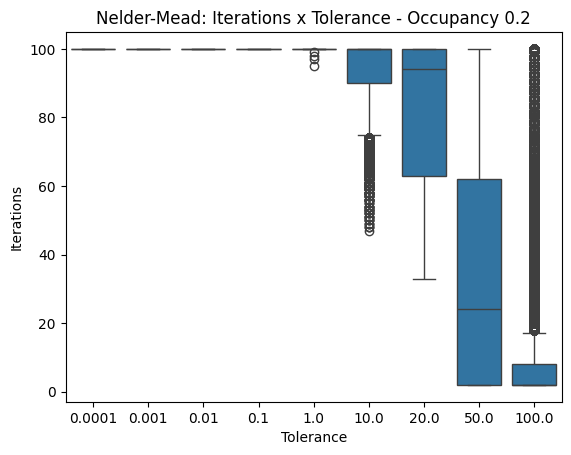

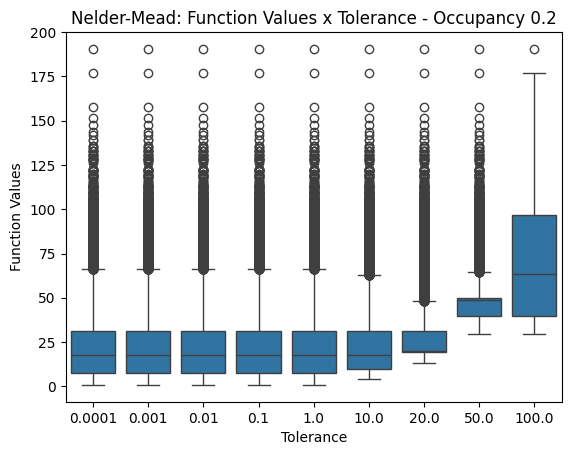

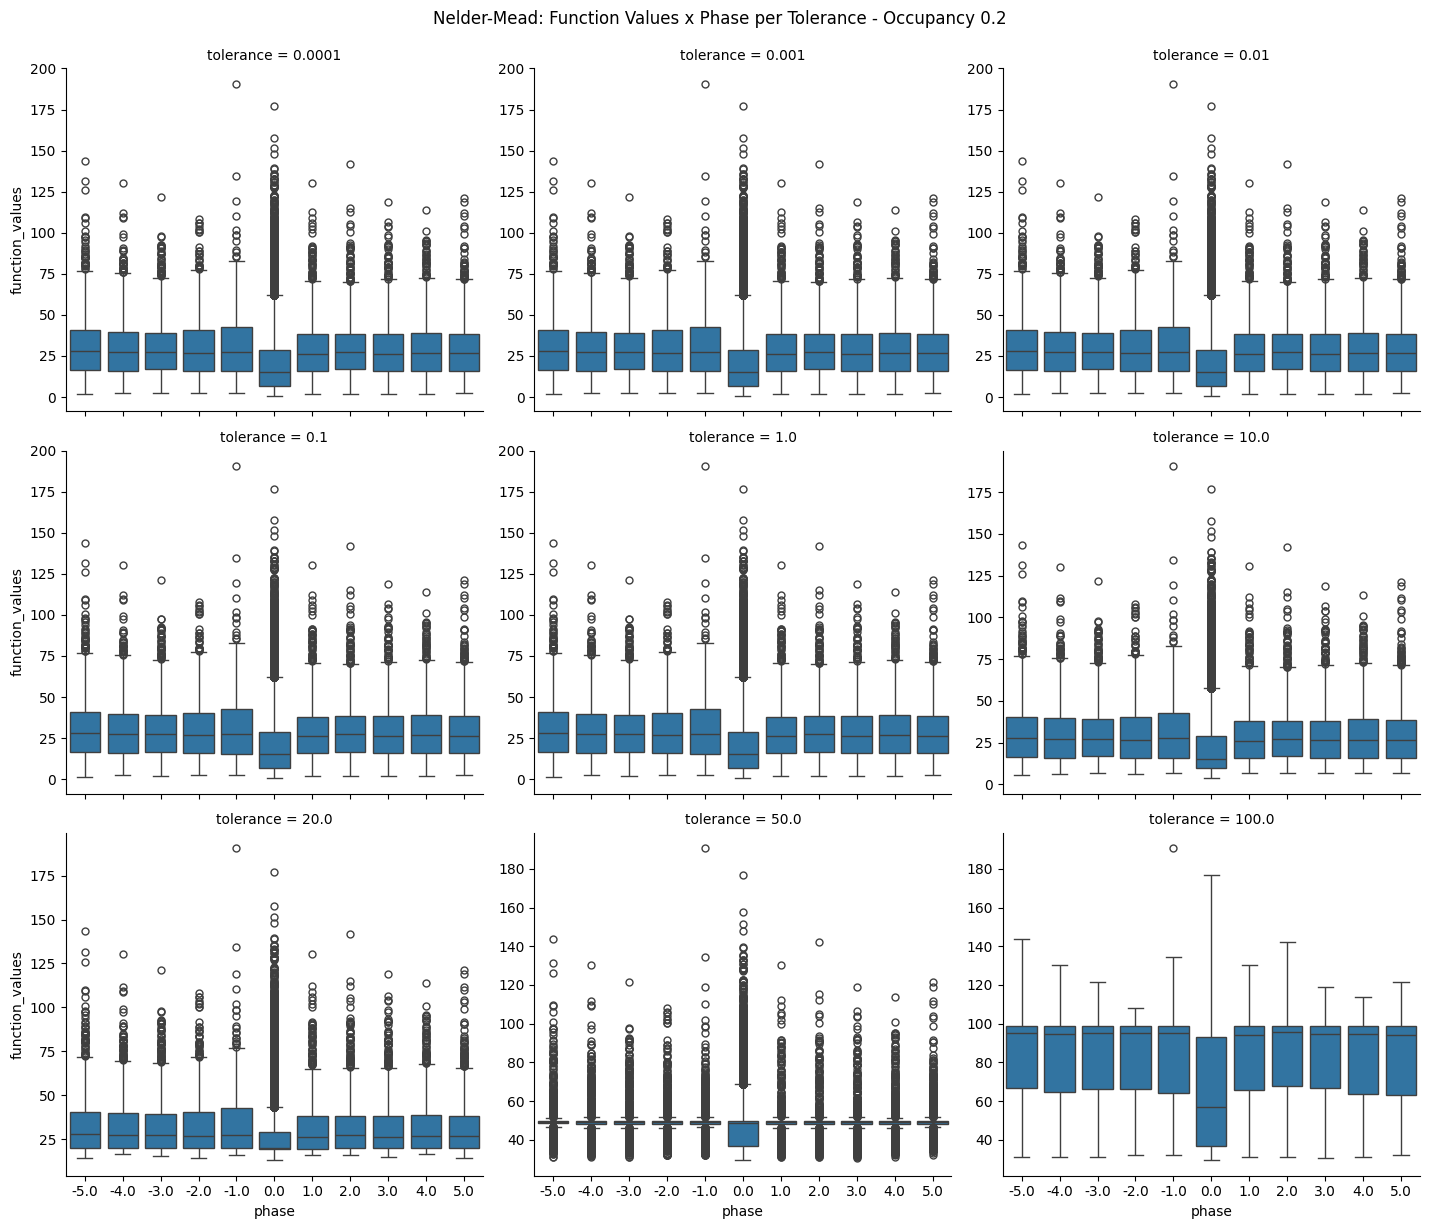

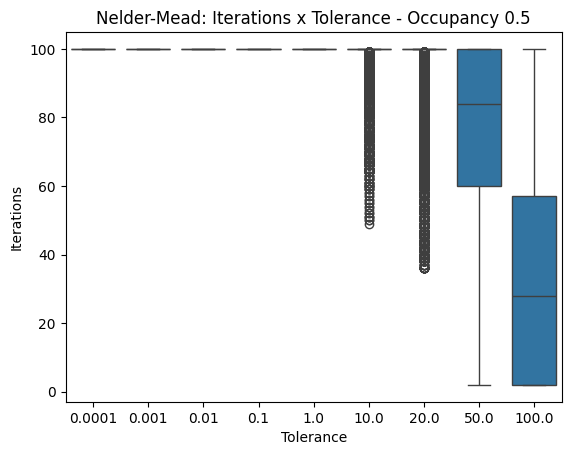

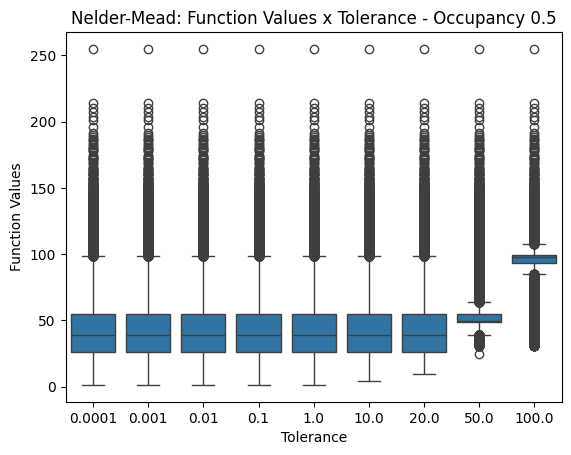

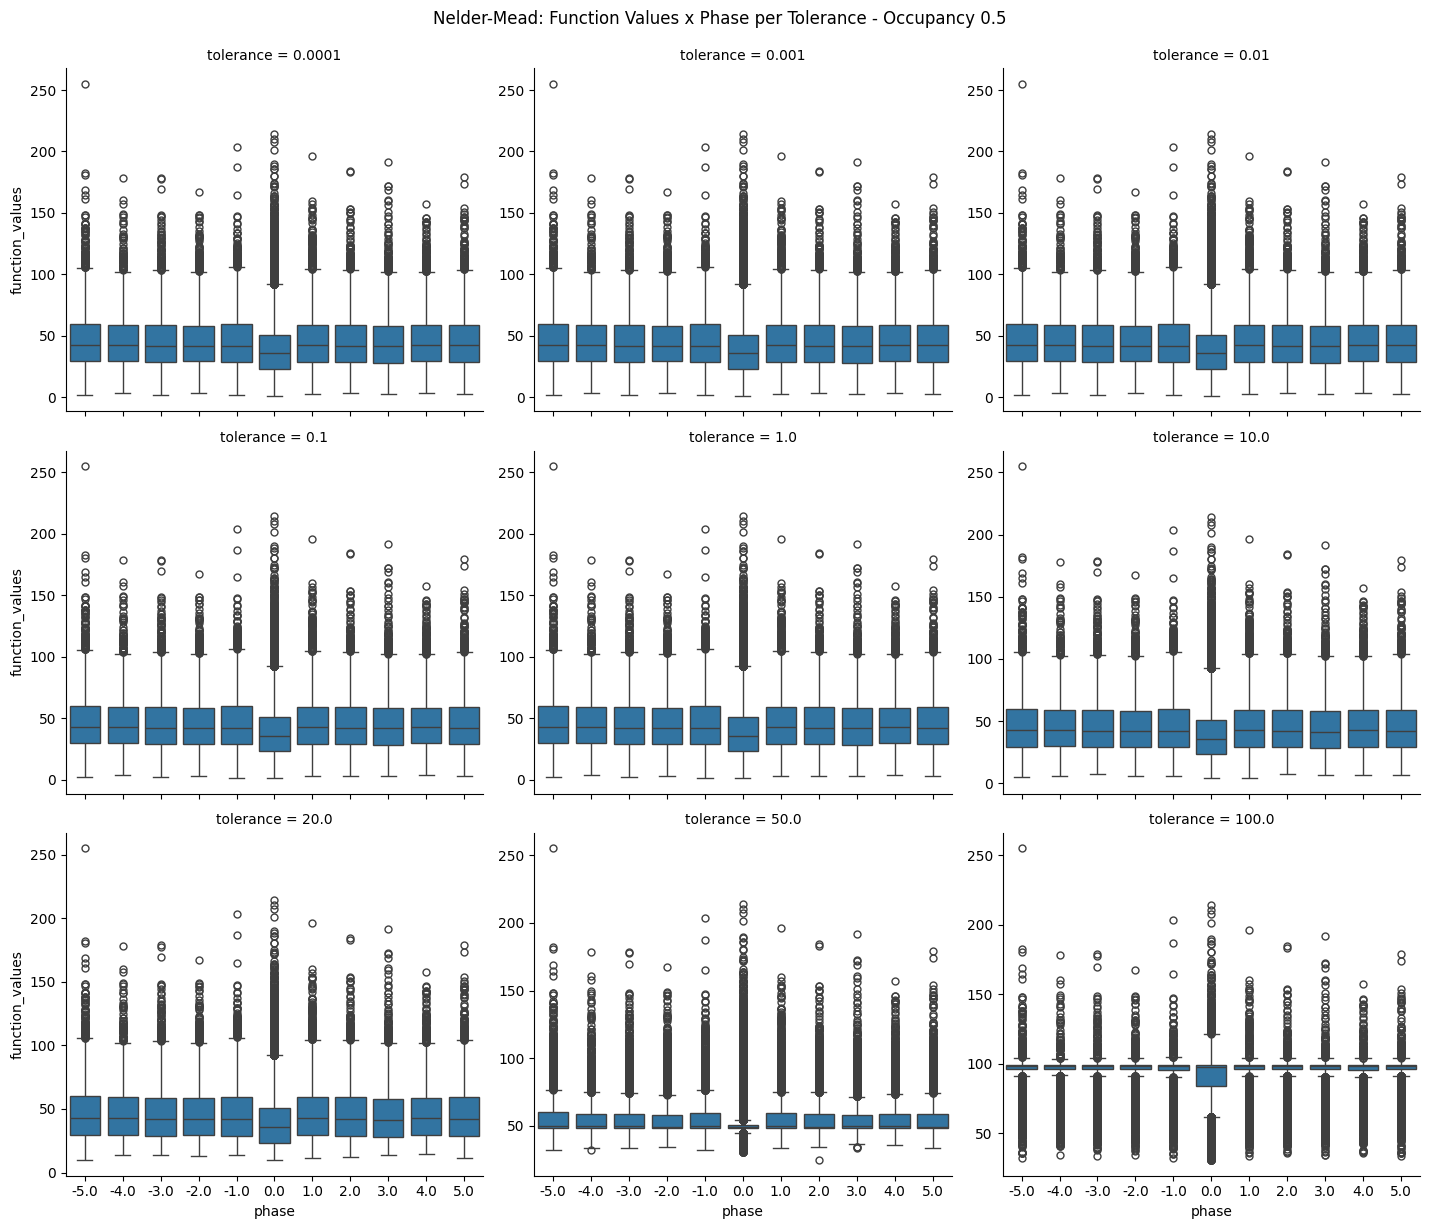

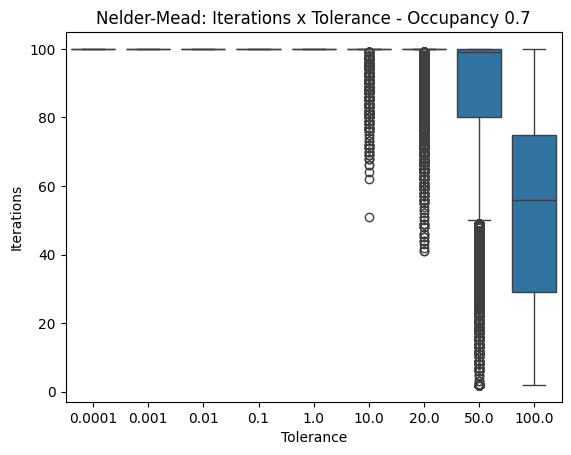

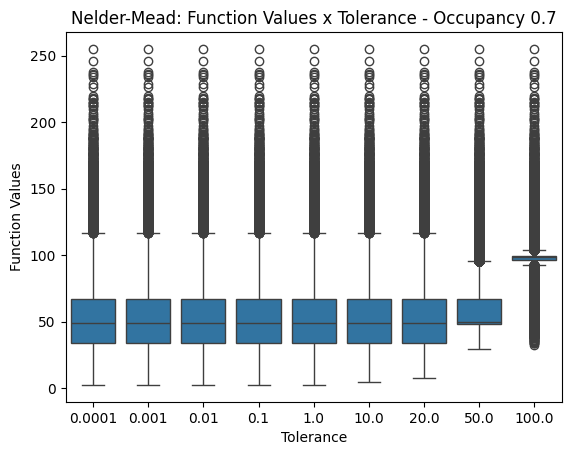

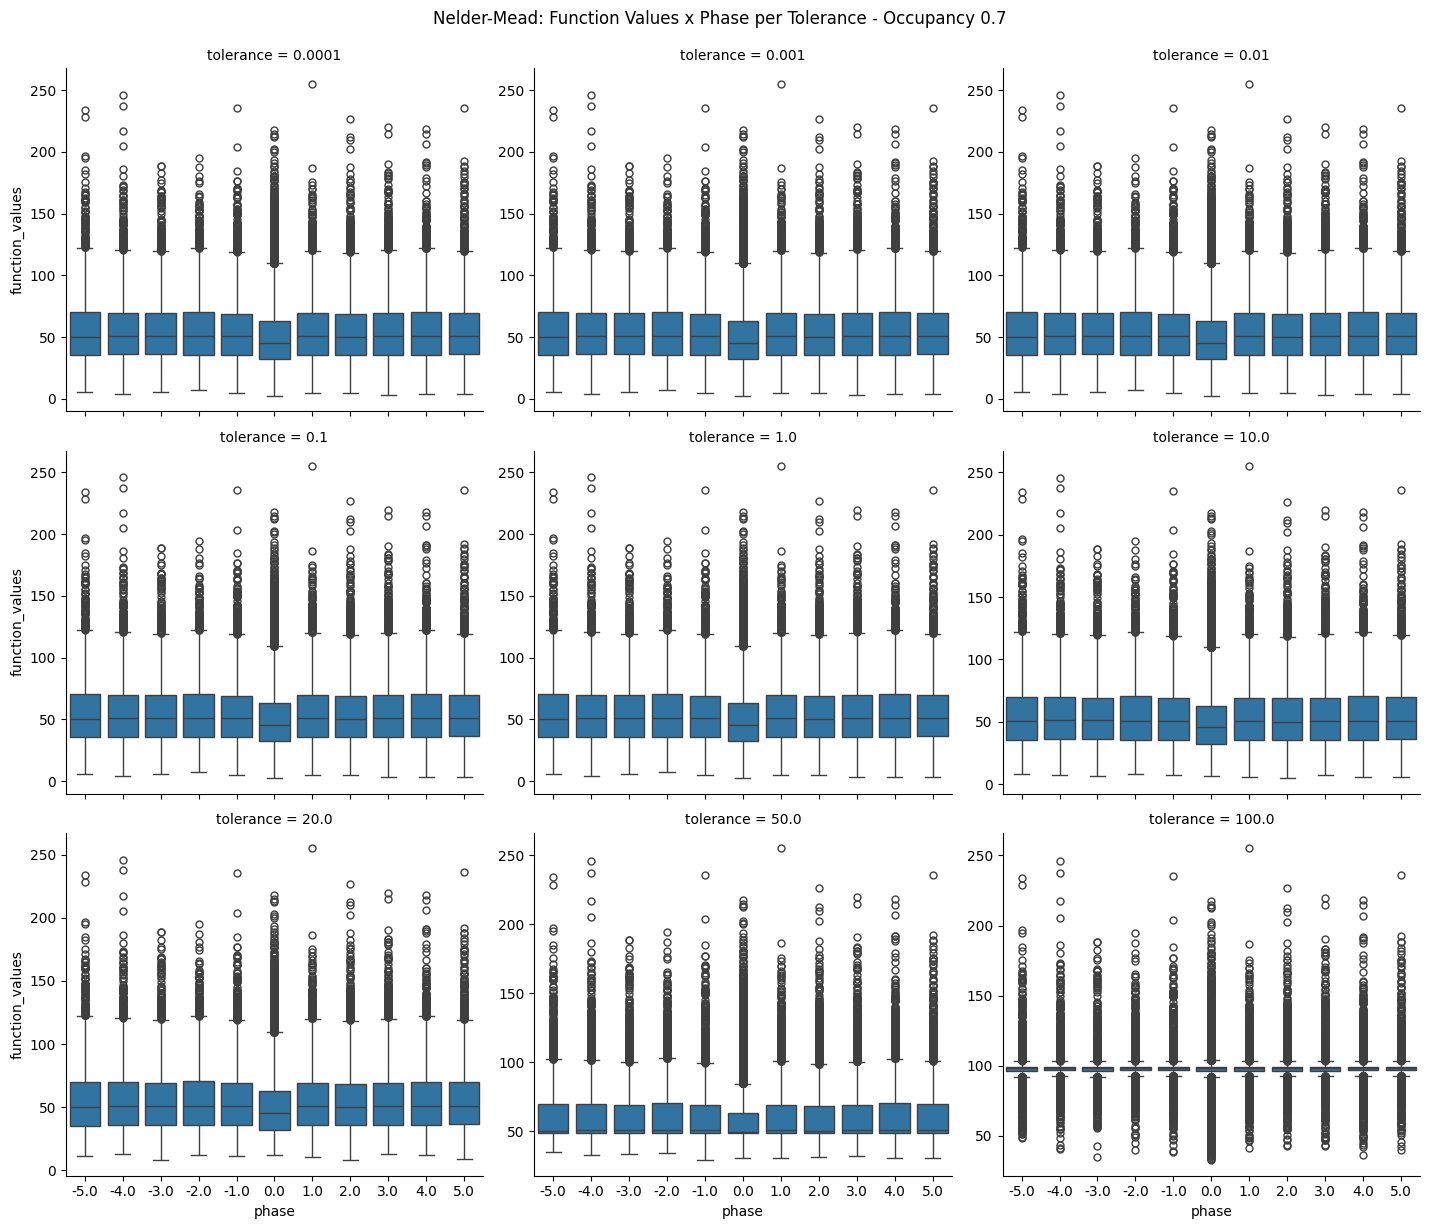

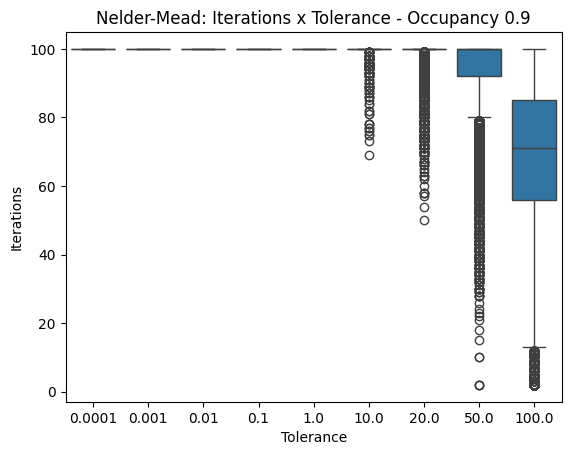

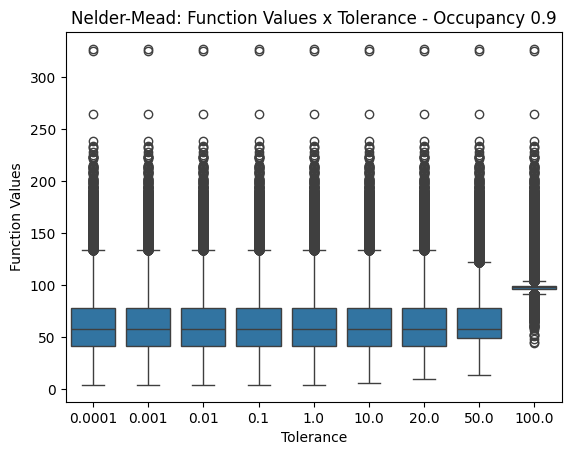

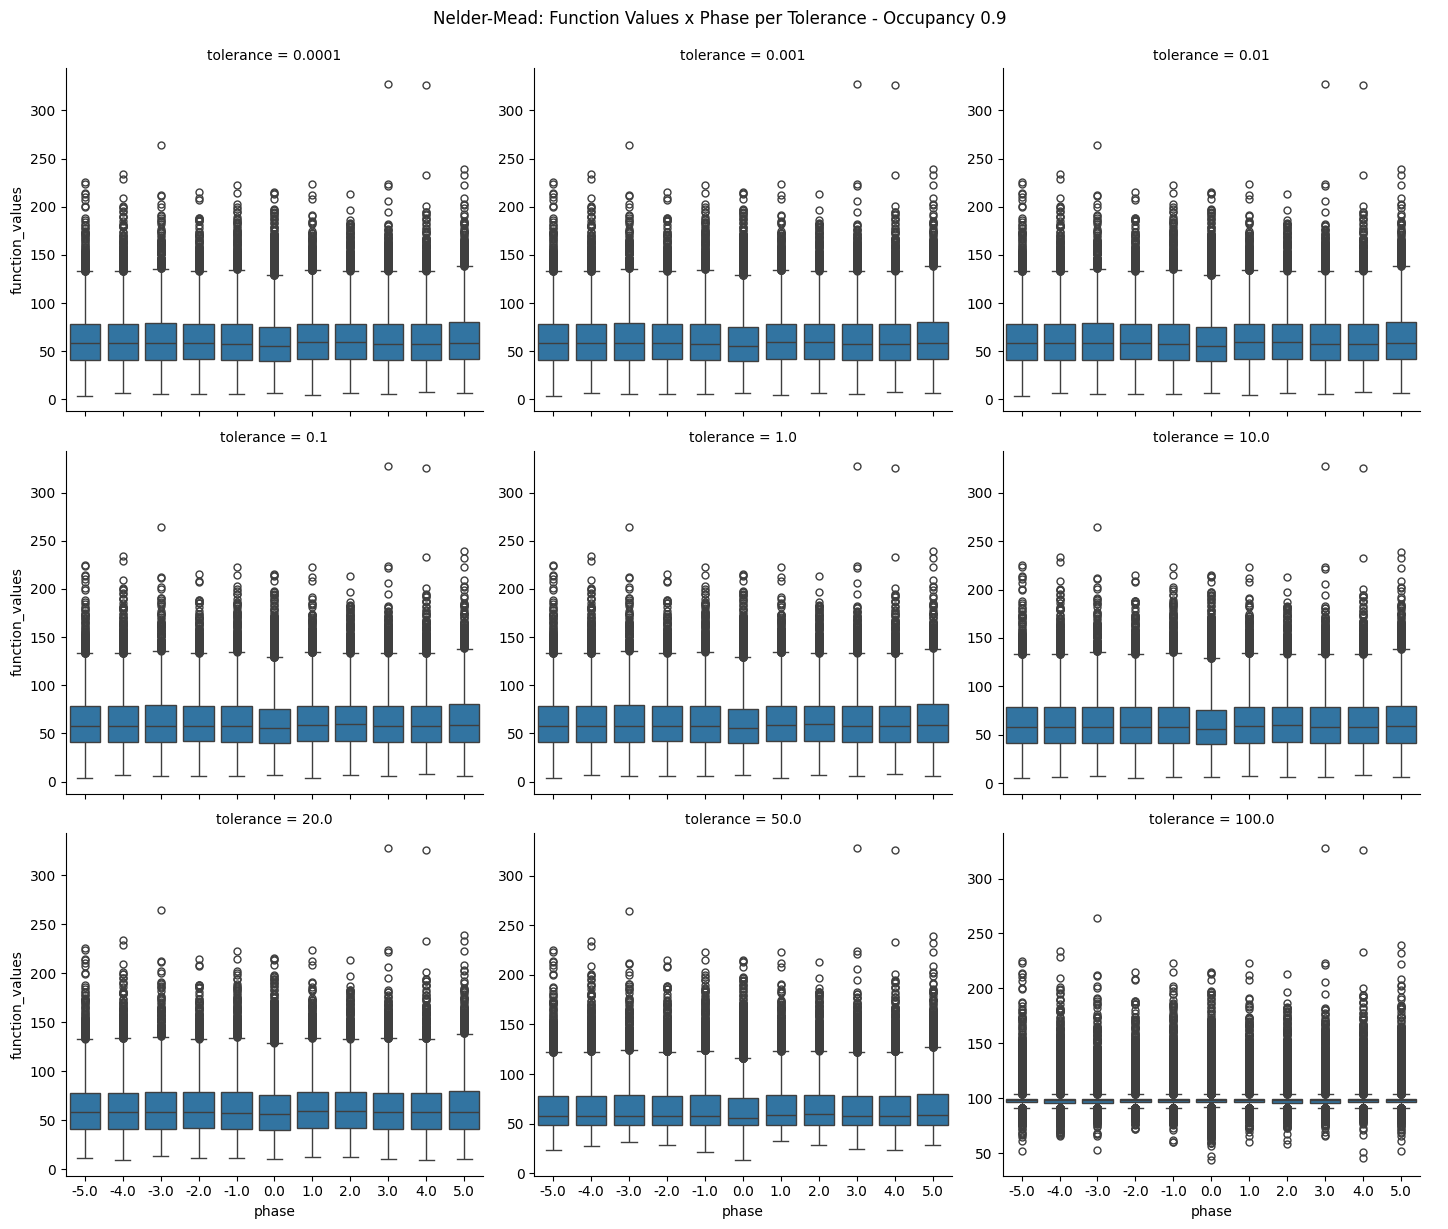

In [10]:
#Boxplot de tolerance por iterations
res = load_results()

for i in range(len(res)):
    ti = pd.DataFrame({'tolerance': res[i]['tolerance'], 'iterations': res[i]['iterations']})
    pf = pd.DataFrame({'phase': res[i]['PhaseSample(4)'], 'function_values': res[i]['function_values'], 'tolerance': res[i]['tolerance']})
    tf = pd.DataFrame({'tolerance': res[i]['tolerance'], 'function_values': res[i]['function_values']})
    
    sns.boxplot(x='tolerance', y='iterations', data=ti)
    plt.xlabel('Tolerance')
    plt.ylabel('Iterations')
    plt.title('Nelder-Mead: Iterations x Tolerance - Occupancy ' + occ_name[i][3:])
    plt.show()

    sns.boxplot(x='tolerance', y='function_values', data=tf)
    plt.xlabel('Tolerance')
    plt.ylabel('Function Values')
    #plt.yscale('log')
    plt.title('Nelder-Mead: Function Values x Tolerance - Occupancy ' + occ_name[i][3:])
    plt.show()

    g = sns.catplot(
        data=pf,
        x='phase',
        y='function_values',
        col='tolerance',   # Cria um gráfico separado para cada valor de tolerância
        col_wrap=3,        # Número máximo de gráficos por linha (ajuste conforme necessário)
        kind='box',        # Define que queremos boxplots
        height=4,          # Altura de cada subgráfico
        aspect=1.2,        # Proporção de largura/altura de cada subgráfico
        sharey=False       # IMPORTANTE: Permite que o eixo Y tenha escalas independentes
    )
    # Ajuste do título principal do grid inteiro
    g.fig.suptitle('Nelder-Mead: Function Values x Phase per Tolerance - Occupancy ' + occ_name[i][3:], y=1.02)
    plt.show()


In [11]:
#Media dos function values e iterações por tolerancia
for i in range(len(res)):
    tf = pd.DataFrame({'tolerance': res[i]['tolerance'], 'function_values': res[i]['function_values'], 'iterations': res[i]['iterations']})
    
    medias = tf.groupby('tolerance')[['function_values', 'iterations']].mean()
    
    print(f"--- Médias da Occupancy {occ_name[i][3:]} ---")
    print(f"{medias}\n")

--- Médias da Occupancy 0.2 ---
           function_values  iterations
tolerance                             
0.0001           21.775499  100.000000
0.0010           21.775499  100.000000
0.0100           21.775499  100.000000
0.1000           21.775499  100.000000
1.0000           21.775499   99.999843
10.0000          22.887454   93.495800
20.0000          27.173947   80.851244
50.0000          45.718844   33.954925
100.0000         66.024969    9.452210

--- Médias da Occupancy 0.5 ---
           function_values  iterations
tolerance                             
0.0001           42.376181  100.000000
0.0010           42.376181  100.000000
0.0100           42.376181  100.000000
0.1000           42.376181  100.000000
1.0000           42.376181  100.000000
10.0000          42.460652   99.470383
20.0000          43.244965   97.291796
50.0000          54.977436   74.859359
100.0000         91.674573   33.681958

--- Médias da Occupancy 0.7 ---
           function_values  iterations
toler